In [7]:
import importlib
import md_Helpers.cavitation_sweep as cs

importlib.reload(cs)

summary = cs.run_cavitation_size_sweep(
    n_fcc_cells_values = [30,28,26,24,22,20],
    conditions=[
        (0.76, 0.70),
    ],
    source_nsteps=1_000_000,
    evolve_nsteps=100_000,
    radius=3.0,
)

#Ran so far:
#(0.76, 0.70), radius=3.0
#(0.76, 0.70), radius=4.0
#(0.76, 0.70), radius=5.0
#(0.71, 0.80), radius=5.0

Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.760/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
Created new cavitation initial state
state_path: /exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.760/kT_0.700/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_3.000/center_box/cavitation_initial.gsd
creation_metadata_path: /exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.760/kT_0.700/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_3.000/center_box/cavitation_creation.hdf5
radius: 3.0
bubble_center: [0. 0. 0.]
particles_removed: 90
N_before: 108000
N_after: 107910
rho_before: 0.7600000328001727
rho_after: 0.7593666994395059
Using GPU device
Final device: <hoomd.device.GPU object at 0x7f04cbff5710>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Cavitation_Evolved_v3/FCC/n_cells_30/source_rho

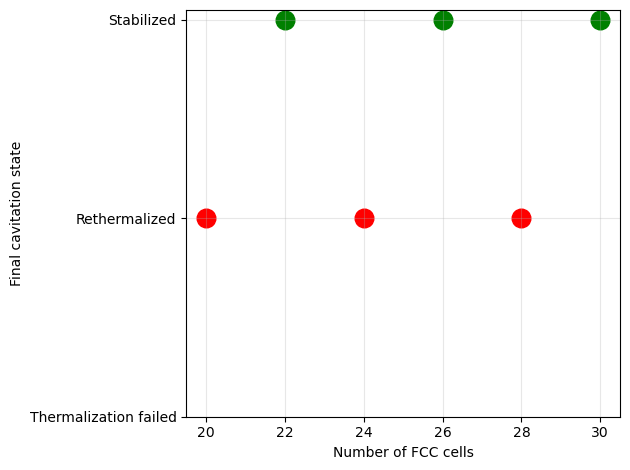

In [8]:
import matplotlib.pyplot as plt

results = summary.sort_values("n_fcc_cells").copy()

y_positions = {
    "not_cavitated": -1,
    "rethermalized": 0,
    "stabilized": 1,
}

colors = {
    "not_cavitated": "black",
    "rethermalized": "red",
    "stabilized": "green",
}

for _, row in results.iterrows():
    outcome = row["outcome"]

    plt.scatter(
        row["n_fcc_cells"],
        y_positions[outcome],
        color=colors[outcome],
        s=180,
    )

plt.yticks(
    [-1, 0, 1],
    ["Thermalization failed", "Rethermalized", "Stabilized"],
)

plt.xticks(results["n_fcc_cells"])
plt.xlabel("Number of FCC cells")
plt.ylabel("Final cavitation state")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()